# The Dogs of the Dow 🐕
### Buy the ten highest-yielding Dow stocks each January — do you really beat the Dow?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

It's the cosiest rule in retail investing: every January, buy the **ten highest-dividend-yield** stocks in the Dow 30, hold them equal-weight for a year, repeat. O'Higgins & Downes sold it in *Beating the Dow* (1991) and it never died. We test it **honestly** — picking each year's Dogs only from the stocks that were *actually in the Dow that year* — and ask the two questions that matter: does it **beat the Dow** (barely, and not for real), and **could you keep the gap** (taxes and dividend traps say no).

> 📓 **This is the plain-language layer.** The *t*-stats, the alpha-vs-beta split and the capacity maths are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (dogs_of_the_dow/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from dogs_of_the_dow import data, strategy

AS_OF = "2026-06-13"
CACHE = os.path.abspath(os.path.join("..", "_cache"))
panel = data.load_panel(end=AS_OF, cache_dir=CACHE)
ann = strategy.annual_returns_from_panel(panel, 2000, 2025, cost_bps=20.0)
summ = strategy.summarize(ann)
exc = ann["excess"].to_numpy()
hac_t = strategy.hac_tstat(exc)
boot = strategy.block_bootstrap_ci(exc)
ab = strategy.alpha_beta(ann)
print(f"Dow panel: {panel['prices'].shape[1]} tickers x {len(panel['prices']):,} days  fingerprint={data.fingerprint(panel)}")
print(f"Dogs CAGR {summ['dogs_cagr']*100:.2f}%  vs Dow {summ['dow_cagr']*100:.2f}%  gap {summ['cagr_gap']*100:+.2f} pts/yr  ({summ['n_years']} yrs)")
print(f"HAC t {hac_t:+.2f}   alpha {ab['alpha']*100:+.2f}%/yr (t {ab['alpha_t']:+.2f})   beta {ab['beta']:.2f}")


$EK: possibly delisted; no price data found  (1d 1927-07-08 -> 2026-06-13)


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}


$WBA: possibly delisted; no timezone found


Dow panel: 46 tickers x 6,673 days  fingerprint=6dfd9e54cba6
Dogs CAGR 8.51%  vs Dow 7.54%  gap +0.98 pts/yr  (26 yrs)
HAC t +0.59   alpha +2.58%/yr (t +1.59)   beta 0.80


## The answer first 🎯

| Question | Answer |
|---|---|
| Did the Dogs beat the Dow over 26 honest years? | **Just barely** — **8.51%/yr** vs **7.54%/yr**, a **+1.0 point/yr** edge. |
| Is that edge statistically real? | **No** — the year-to-year gap has *t* = **0.59** and a range from **-2.15%** to **+3.59%** that includes zero. |
| So what *is* it? | A **lower-risk, higher-yield** slice of the Dow (beta **0.8**) — a value tilt, not a Dow secret — and the dividends get **taxed** every year. |

## 1 · The claim

*"Each January, buy the 10 highest-dividend-yield stocks in the Dow 30, equal-weight, hold a year, repeat. This **Dogs of the Dow** beats the Dow itself."* The intuition: a high yield means a beaten-down blue chip that's due to mean-revert, and you collect fat dividends while you wait.

## 2 · So what?

If a rule a child could follow beat the Dow, the whole edifice of stock-picking would owe it an apology — and every January article telling you to do it would be right. The stakes are exactly that simple, so it deserves a fair, *literal*, survivorship-honest test.

## 3 · How would we even know?

Here's the trap most write-ups fall into: **the Dow's membership changes.** If you build the Dogs from *today's* 30 names back to 2000, you've quietly deleted the losers that got kicked out (GM, Kodak) and back-dated the winners that got added (Apple, Nvidia) — that alone can manufacture a fake win. So we encode a **point-in-time** membership list and pick each January's Dogs **only from the stocks that were in the Dow that January**. Then we race the Dogs against the **Dow on the same total-return basis** (the DIA ETF), pay 20 bps on what we trade, and run it over the **26 years (2000–2025)** we can do correctly. Two members we can't price honestly (Kodak, Walgreens) are **left out and named**, not swept under the rug.

## 4 · The teardown — let's actually look

First, $1 in the Dogs vs $1 in the Dow.

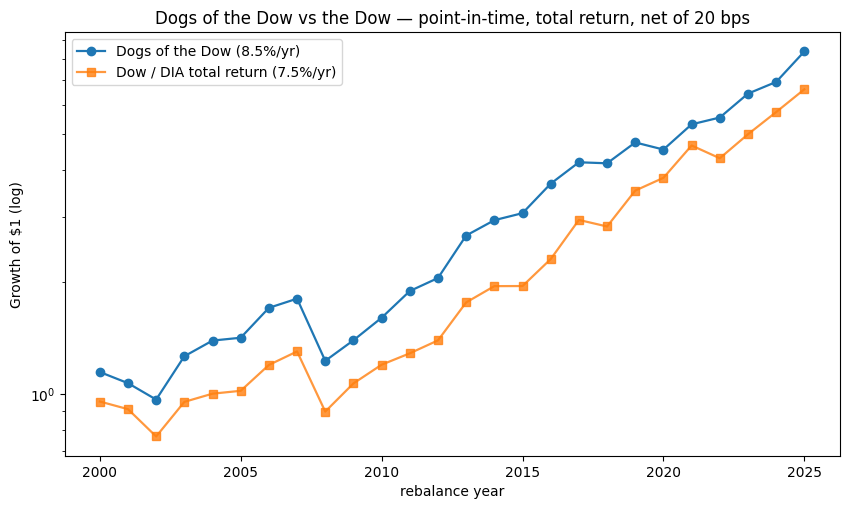

In [2]:
eq_dogs = (1 + ann['dogs']).cumprod()
eq_dow = (1 + ann['dow']).cumprod()
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(eq_dogs.index, eq_dogs.values, marker='o', lw=1.6, label=f"Dogs of the Dow ({summ['dogs_cagr']*100:.1f}%/yr)")
ax.plot(eq_dow.index, eq_dow.values, marker='s', lw=1.6, alpha=.8, label=f"Dow / DIA total return ({summ['dow_cagr']*100:.1f}%/yr)")
ax.set_yscale('log'); ax.set_ylabel('Growth of $1 (log)'); ax.set_xlabel('rebalance year')
ax.set_title('Dogs of the Dow vs the Dow — point-in-time, total return, net of 20 bps'); ax.legend(); plt.show()

The Dogs line ends a little higher — but look how *close* the two lines hug each other for 26 years. This isn't a runaway free lunch; it's a hair's-breadth lead that could easily be luck. Let's look at the year-by-year gap to feel how noisy it is.

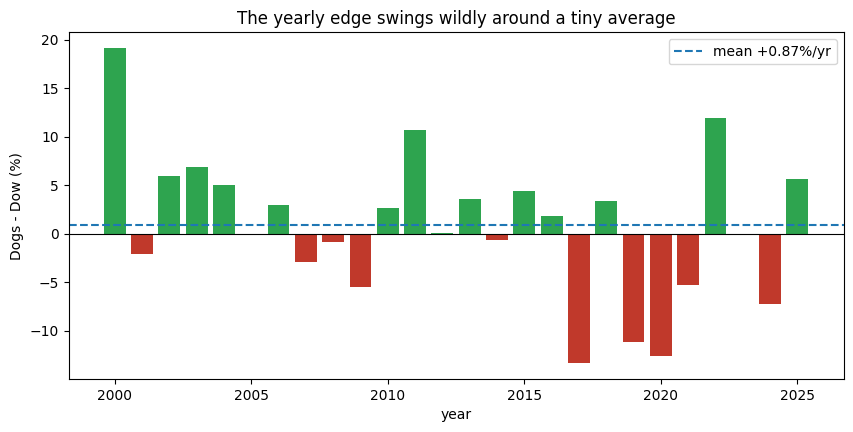

Dogs won 14/26 years


In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#2ea44f' if e > 0 else '#c0392b' for e in ann['excess']]
ax.bar(ann.index, ann['excess']*100, color=colors)
ax.axhline(0, color='k', lw=.8)
ax.axhline(ann['excess'].mean()*100, color='C0', ls='--', label=f"mean {ann['excess'].mean()*100:+.2f}%/yr")
ax.set_ylabel('Dogs - Dow (%)'); ax.set_xlabel('year'); ax.set_title('The yearly edge swings wildly around a tiny average'); ax.legend(); plt.show()
print(f"Dogs won {(ann['excess']>0).sum()}/{len(ann)} years")

The Dogs won only **14 of 26** years — barely a coin flip — and the bars swing from **+19%** to **−13%**. A +0.9%/yr *average* sitting inside that much noise is exactly what 'not statistically real' looks like.

Now the catch the brochures skip: what does 'highest yield' actually buy you in a crisis?

In [4]:
rebal = pd.Timestamp('2008-12-31')
members = data.members_asof(rebal)
yy = {}
for t in members:
    if t in panel['prices'].columns:
        dv = panel['divs'][t].dropna() if t in panel['divs'].columns else pd.Series(dtype=float)
        v = strategy.trailing_yield(panel['prices'][t].dropna(), dv, rebal)
        if np.isfinite(v) and v > 0: yy[t] = v
top = sorted(yy, key=lambda k: yy[k], reverse=True)[:10]
print('Jan-2009 Dogs basket (trailing yield at rebalance):')
for t in top: print(f'  {t:5s} {yy[t]*100:5.1f}%')

Jan-2009 Dogs basket (trailing yield at rebalance):
  C      22.8%
  BAC    20.8%
  DD     17.6%
  PFE    15.1%
  VZ     12.8%
  GE     11.1%
  KFT     9.7%
  MRK     9.1%
  JPM     7.4%
  AA      7.1%


The January-2009 basket is a **dividend trap museum**: Citigroup at ~23% trailing yield, Bank of America at ~21% — financials that had collapsed and were *about to cut their dividends to pennies*. The 'highest yield' screen doesn't find bargains here; it finds the market pricing in a disaster.

## 5 · The verdict

- **Beats the Dow? → barely, and not for real.** +1.0 pts/yr, but *t* = 0.59 and the range of the yearly edge (-2.15% to +3.59%) straddles zero. **Signal → Weak.**
- **What it really is:** a **lower-beta (0.8), higher-yield** slice of the Dow — a value tilt you were always paid for, not a Dow-specific secret.
- **Keep the gap? → no.** Low turnover (23%/yr) means trading cost barely bites — but the fat dividends are **taxed every year**, and the screen courts dividend traps. **Tradability → Fragile.**

## 6 · Could you actually trade it?

You can run it in a brokerage account with a spreadsheet — capacity isn't the issue. The issue is that the product is *a defensive value tilt* whose ~1-point lead isn't even statistically real, and which you'd hold in a **deliberately high-dividend** basket that a taxable investor pays income tax on every single year. In a taxable account the after-tax Dogs and the Dow are a wash or worse.

## 7 · Going further 🚪

- The **'Small Dogs'** (the 5 lowest-priced of the 10) — does the smaller-cap tilt add anything, or just more noise?
- Replace trailing yield with a **forward / cut-adjusted** yield — does dodging the dividend traps (Citi, BofA in 2009) recover a real edge?
- Run it on the **S&P 100** instead of the Dow 30 — does a wider high-yield net behave differently? Fork it and try.